In [1]:
# ============================================================
# CELL 1: SETUP
# ============================================================
import os, re, gc, copy, time, random, warnings, json
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T

from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, accuracy_score
)
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s)
    os.environ['PYTHONHASHSEED'] = str(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Device: cuda
GPU: Tesla P100-PCIE-16GB
VRAM: 17.1 GB


In [ ]:
# ============================================================
# CELL 2: CONFIGURATION
# ============================================================
class CFG:
    data_root = "/kaggle/input/endoscopic-bladder-tissue-classification-dataset/EndoscopicBladderTissue"

    class_names = ['HGC', 'LGC', 'Normal']  # Combined NST + NTL into Normal
    num_classes = 3

    # Preprocessing
    image_resize = 512
    clahe_clip = 2.0
    clahe_grid = (8, 8)

    # Multi-scale patches
    patch_scales = [96, 128, 192]
    patch_output_size = 224
    patch_stride_frac = 0.5
    min_tissue = 0.50
    max_bright = 240
    min_bright = 20
    min_sat = 12
    min_focus = 10.0
    top_quality_frac = 0.70

    # Limit patches per image to control memory and speed
    max_patches_per_image = 40  # cap per image during feature extraction

    # Feature extraction
    feat_batch = 32
    feat_dim = 1024  # updated after backbone load

    # CLAM
    mil_hidden = 256
    mil_dropout = 0.25
    clam_k_sample = 8
    feat_noise_std = 0.03
    feat_drop_p = 0.1
    inst_loss_w = 0.3
    bag_loss_w = 1.0

    # Training
    epochs = 80            # reduced — we add early stopping
    patience = 15          # early stopping patience
    lr = 1e-4
    wd = 5e-5
    grad_clip = 1.0
    max_patches_train = 300
    max_patches_test = 500

    # Augmentation
    n_augments = 2

    # Ensemble
    n_ensemble = 3

    # Class weights — computed from data (filled in Cell 3)
    class_weights = None

IMNET_MEAN = torch.tensor([0.485,0.456,0.406]).view(1,3,1,1).to(DEVICE)
IMNET_STD  = torch.tensor([0.229,0.224,0.225]).view(1,3,1,1).to(DEVICE)

print("✓ Config loaded")

✓ Config loaded


In [ ]:
# ============================================================
# CELL 3: DATASET LOADING + CLASS WEIGHTS
# ============================================================
records = []
pattern = re.compile(r'pt[_]?0*(\d+)')

# Map original labels to combined labels
label_mapping = {
    'HGC': 'HGC',
    'LGC': 'LGC',
    'NST': 'Normal',  # Combine NST and NTL
    'NTL': 'Normal'
}

for label in os.listdir(CFG.data_root):
    class_path = os.path.join(CFG.data_root, label)
    if not os.path.isdir(class_path):
        continue
    if label not in label_mapping:
        print(f"  ⚠ Skipping unknown folder: {label}")
        continue
    for img_name in os.listdir(class_path):
        match = pattern.search(img_name)
        if match:
            patient_id = int(match.group(1))
            records.append({
                "path": os.path.join(class_path, img_name),
                "label": label_mapping[label],  # Use mapped label
                "original_label": label,  # Keep original for reference
                "patient": patient_id,
                "filename": img_name
            })

df = pd.DataFrame(records)
class_to_idx = {c: i for i, c in enumerate(CFG.class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df["target"] = df["label"].map(class_to_idx)

print(f"Total images: {len(df)}")
print(f"Total patients: {df.patient.nunique()}")
print(f"Classes: {CFG.class_names}")
print(f"Mapping: {class_to_idx}")

# ---- Compute class weights (inverse frequency) ----
class_counts = df['label'].value_counts()
total = len(df)
weights = []
print(f"\nClass distribution and weights:")
for cls in CFG.class_names:
    count = class_counts.get(cls, 0)
    # Inverse frequency, normalized
    w = total / (CFG.num_classes * max(count, 1))
    weights.append(w)
    print(f"  {cls}: {count} images ({count/total*100:.1f}%) → weight={w:.3f}")

CFG.class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print(f"\nClass weights tensor: {CFG.class_weights}")

# ---- Patient summary ----
PATIENTS = sorted(df.patient.unique())
N_PATIENTS = len(PATIENTS)

print(f"\n{'Patient':<10} {'#Imgs':<8} {'Distribution'}")
print("-" * 65)
for pid in PATIENTS:
    pdf = df[df.patient == pid]
    counts = Counter(pdf.label.values)
    dist = ", ".join(f"{k}:{v}" for k, v in sorted(counts.items()))
    print(f"  P{pid:<8} {len(pdf):<8} {dist}")

print(f"\n✓ {N_PATIENTS} patients, {len(df)} images, {CFG.num_classes} classes")

Total images: 1713
Total patients: 14
Classes: ['HGC', 'LGC', 'NST', 'NTL']
Mapping: {'HGC': 0, 'LGC': 1, 'NST': 2, 'NTL': 3}

Class distribution and weights:
  HGC: 469 images (27.4%) → weight=0.913
  LGC: 647 images (37.8%) → weight=0.662
  NST: 463 images (27.0%) → weight=0.925
  NTL: 134 images (7.8%) → weight=3.196

Class weights tensor: tensor([0.9131, 0.6619, 0.9249, 3.1959], device='cuda:0')

Patient    #Imgs    Distribution
-----------------------------------------------------------------
  P1        491      HGC:88, LGC:128, NST:224, NTL:51
  P2        302      HGC:75, LGC:112, NST:87, NTL:28
  P3        172      HGC:102, LGC:26, NST:34, NTL:10
  P4        234      HGC:110, LGC:79, NST:30, NTL:15
  P5        175      HGC:46, LGC:70, NST:39, NTL:20
  P6        122      HGC:40, LGC:76, NST:5, NTL:1
  P7        28       HGC:8, LGC:14, NTL:6
  P8        57       LGC:45, NST:9, NTL:3
  P9        9        LGC:9
  P10       51       LGC:51
  P11       46       LGC:11, NST:35
  P12  

In [4]:
# ============================================================
# CELL 4: LAB NORMALIZATION + CLAHE
# ============================================================
class LabNormalizer:
    def __init__(self):
        self.ref = None

    def fit(self, images_bgr):
        stats = {'L': [], 'a': [], 'b': []}
        for img in images_bgr:
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
            for i, ch in enumerate(['L', 'a', 'b']):
                stats[ch].append({
                    'm': lab[:,:,i].mean(),
                    's': lab[:,:,i].std() + 1e-6
                })
        self.ref = {
            ch: {'m': np.median([s['m'] for s in stats[ch]]),
                 's': np.median([s['s'] for s in stats[ch]])}
            for ch in ['L', 'a', 'b']
        }
        return self

    def transform(self, img_bgr):
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
        for i, ch in enumerate(['L', 'a', 'b']):
            c = lab[:,:,i]
            sm, ss = c.mean(), c.std() + 1e-6
            lab[:,:,i] = np.clip(
                (c - sm) * (self.ref[ch]['s'] / ss) + self.ref[ch]['m'], 0, 255
            )
        lab = lab.astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=CFG.clahe_clip, tileGridSize=CFG.clahe_grid)
        lab[:,:,0] = clahe.apply(lab[:,:,0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


def load_image(path, norm=None):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    h, w = img.shape[:2]
    s = CFG.image_resize / max(h, w)
    if s != 1:
        img = cv2.resize(img, (int(w*s), int(h*s)), interpolation=cv2.INTER_AREA)
    if norm:
        img = norm.transform(img)
    return img


def fit_normalizer_excluding(exclude_pid=None):
    """
    Fit normalizer on all patients EXCEPT exclude_pid.
    For proper LOPO, the test patient should not influence normalization.
    """
    samples = []
    for pid in PATIENTS:
        if pid == exclude_pid:
            continue
        for fp in df[df.patient == pid].path.values[:5]:
            try:
                img = cv2.imread(fp)
                if img is not None:
                    h, w = img.shape[:2]
                    s = CFG.image_resize / max(h, w)
                    if s != 1:
                        img = cv2.resize(img, (int(w*s), int(h*s)))
                    samples.append(img)
            except:
                pass
    return LabNormalizer().fit(samples)


# Fit a global normalizer for feature extraction
# (Per-fold normalizers used during LOPO)
global_normalizer = fit_normalizer_excluding(exclude_pid=None)
print(f"✓ Global normalizer fitted")

✓ Global normalizer fitted


In [5]:
# ============================================================
# CELL 5: MULTI-SCALE PATCHES + QUALITY FILTER
# ============================================================

def compute_quality(patch_bgr):
    hsv = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2HSV)
    v = hsv[:,:,2].astype(float)
    s = hsv[:,:,1].astype(float)

    mask = (v < CFG.max_bright) & (v > CFG.min_bright) & (s > CFG.min_sat)
    tissue_frac = mask.sum() / mask.size
    if tissue_frac < CFG.min_tissue:
        return -1.0

    gray = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2GRAY)
    focus = cv2.Laplacian(gray, cv2.CV_64F).var()
    if focus < CFG.min_focus:
        return -1.0

    focus_norm = min(focus / 100.0, 1.0)
    sat_std = s[mask].std() / 50.0 if mask.sum() > 10 else 0
    sat_norm = min(sat_std, 1.0)
    edges = cv2.Canny(gray, 50, 150)
    edge_density = min(edges.sum() / (255.0 * edges.size) * 10, 1.0)

    return 0.3*tissue_frac + 0.3*focus_norm + 0.2*sat_norm + 0.2*edge_density


def extract_multiscale_patches(image_bgr, max_patches=None):
    """
    Extract patches at multiple scales.
    Keep top quality fraction, then cap at max_patches.
    """
    if max_patches is None:
        max_patches = CFG.max_patches_per_image

    H, W = image_bgr.shape[:2]
    candidates = []

    for scale in CFG.patch_scales:
        if scale > min(H, W):
            continue
        stride = max(1, int(scale * CFG.patch_stride_frac))
        for y in range(0, H - scale + 1, stride):
            for x in range(0, W - scale + 1, stride):
                crop = image_bgr[y:y+scale, x:x+scale]
                q = compute_quality(crop)
                if q > 0:
                    resized = cv2.resize(
                        crop,
                        (CFG.patch_output_size, CFG.patch_output_size),
                        interpolation=cv2.INTER_AREA
                    )
                    candidates.append((resized, q, scale))

    if len(candidates) == 0:
        return [], [], []

    # Sort by quality, keep top fraction
    candidates.sort(key=lambda x: x[1], reverse=True)
    n_keep = max(1, int(len(candidates) * CFG.top_quality_frac))
    candidates = candidates[:n_keep]

    # Cap at max_patches
    if len(candidates) > max_patches:
        candidates = candidates[:max_patches]

    return ([c[0] for c in candidates],
            [c[1] for c in candidates],
            [c[2] for c in candidates])


# Test
test_img = load_image(df.iloc[0].path, global_normalizer)
tp, ts, tsc = extract_multiscale_patches(test_img)
print(f"✓ Test: {test_img.shape} → {len(tp)} patches (cap={CFG.max_patches_per_image})")
if tsc:
    for s, c in sorted(Counter(tsc).items()):
        print(f"    Scale {s}: {c}")
del tp, ts, tsc, test_img; gc.collect()

✓ Test: (512, 512, 3) → 40 patches (cap=40)
    Scale 96: 19
    Scale 128: 16
    Scale 192: 5


3848

In [6]:
# ============================================================
# CELL 6: CYSTOSCOPY AUGMENTATION
# ============================================================

class GaussianNoise:
    def __init__(self, std=0.02):
        self.std = std
    def __call__(self, t):
        return torch.clamp(t + torch.randn_like(t) * self.std, 0, 1)

class CystoAugmentor:
    def __init__(self):
        self.transform = T.Compose([
            T.RandomRotation(360),
            T.RandomHorizontalFlip(0.5),
            T.RandomVerticalFlip(0.5),
            T.ColorJitter(brightness=0.2, contrast=0.2,
                          saturation=0.15, hue=0.01),
            T.RandomApply([T.GaussianBlur(3, sigma=(0.1, 1.0))], p=0.2),
            T.RandomApply([GaussianNoise(0.02)], p=0.15),
            T.RandomAffine(degrees=0, translate=(0.05, 0.05),
                           scale=(0.95, 1.05)),
        ])

    def __call__(self, tensor_chw):
        return self.transform(tensor_chw)

augmentor = CystoAugmentor()
print("✓ Augmentor ready")

✓ Augmentor ready


In [7]:
# ============================================================
# CELL 7: DUAL BACKBONE — DINOv2 + DenseNet121
# ============================================================

def load_dinov2():
    print("  Loading DINOv2...")
    try:
        model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
        feat_dim = 384
        print(f"  ✓ DINOv2 ViT-S/14 — dim={feat_dim}")
    except Exception as e:
        print(f"  ⚠ DINOv2 failed: {e}")
        try:
            model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16')
            feat_dim = 384
            print(f"  ✓ DINO ViT-S/16 fallback — dim={feat_dim}")
        except Exception as e2:
            print(f"  ⚠ All DINO failed: {e2}")
            return None, 0
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model.to(DEVICE), feat_dim


def load_densenet():
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    feat_dim = model.classifier.in_features
    model.classifier = nn.Identity()
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model.to(DEVICE), feat_dim


print("Loading backbones...")
dino_model, dino_dim = load_dinov2()
dense_model, dense_dim = load_densenet()
print(f"  ✓ DenseNet121 — dim={dense_dim}")

if dino_model is not None:
    CFG.feat_dim = dino_dim + dense_dim
    backbone_desc = f"DINOv2({dino_dim}) + DenseNet({dense_dim})"
else:
    CFG.feat_dim = dense_dim
    backbone_desc = f"DenseNet({dense_dim})"

print(f"\n✓ Feature dim: {CFG.feat_dim} [{backbone_desc}]")

Loading backbones...
  Loading DINOv2...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 334MB/s]


  ✓ DINOv2 ViT-S/14 — dim=384
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 192MB/s]


  ✓ DenseNet121 — dim=1024

✓ Feature dim: 1408 [DINOv2(384) + DenseNet(1024)]


In [8]:
# ============================================================
# CELL 8: FEATURE EXTRACTION — PER IMAGE
# ============================================================

def bgr_to_tensor(patch_bgr):
    rgb = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2RGB)
    return torch.from_numpy(rgb).permute(2, 0, 1).float() / 255.0


@torch.no_grad()
def extract_dual_features(tensor_list):
    """Extract concatenated features from both backbones."""
    all_feats = []
    bs = CFG.feat_batch
    for i in range(0, len(tensor_list), bs):
        batch = torch.stack(tensor_list[i:i+bs]).to(DEVICE)
        batch_norm = (batch - IMNET_MEAN) / IMNET_STD
        parts = []

        if dino_model is not None:
            dino_out = dino_model(batch_norm)
            if isinstance(dino_out, dict):
                dino_feats = dino_out.get('x_norm_clstoken', None)
                if dino_feats is None:
                    for v in dino_out.values():
                        if isinstance(v, torch.Tensor):
                            dino_feats = v; break
            else:
                dino_feats = dino_out
            if dino_feats.dim() > 2:
                dino_feats = dino_feats[:, 0, :]
            parts.append(dino_feats.cpu())

        dense_feats = dense_model(batch_norm)
        parts.append(dense_feats.cpu())

        all_feats.append(torch.cat(parts, dim=1))

    return torch.cat(all_feats, 0)


def extract_all_image_features(use_augmentation=False):
    """
    Extract features per image. Each image = bag of patch features.
    
    Controls memory by:
    1. Capping patches per image at max_patches_per_image
    2. Extracting and storing on CPU
    3. Augmented patches share the same cap
    """
    tag = "WITH" if use_augmentation else "WITHOUT"
    n_aug = CFG.n_augments if use_augmentation else 0
    print(f"\n{'='*55}")
    print(f"  Extracting features {tag} augmentation")
    if use_augmentation:
        print(f"  Each patch → 1 orig + {n_aug} aug = {1+n_aug}x")
    print(f"  Max patches per image: {CFG.max_patches_per_image}")
    print(f"{'='*55}\n")

    image_data = []
    skipped = 0
    total_patches = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Images"):
        try:
            img = load_image(row.path, global_normalizer)
        except:
            skipped += 1
            continue

        patches, _, _ = extract_multiscale_patches(img)
        if len(patches) == 0:
            skipped += 1
            continue

        # Build tensors
        tensors = []
        for p in patches:
            t = bgr_to_tensor(p)
            tensors.append(t)
            if use_augmentation:
                for _ in range(n_aug):
                    tensors.append(augmentor(bgr_to_tensor(p)))

        # Cap total tensors to avoid memory issues
        max_total = CFG.max_patches_per_image * (1 + n_aug)
        if len(tensors) > max_total:
            indices = random.sample(range(len(tensors)), max_total)
            tensors = [tensors[i] for i in sorted(indices)]

        feats = extract_dual_features(tensors)

        image_data.append({
            'features': feats,          # stored on CPU
            'label': row.target,
            'label_name': row.label,
            'patient': row.patient,
            'path': row.path,
            'n_patches': feats.shape[0]
        })
        total_patches += feats.shape[0]

    # Memory estimate
    mem_bytes = sum(d['features'].element_size() * d['features'].nelement()
                    for d in image_data)

    print(f"\n✓ {tag} augmentation:")
    print(f"  Images: {len(image_data)} ({skipped} skipped)")
    print(f"  Total patches: {total_patches}")
    print(f"  Memory: {mem_bytes/1e9:.2f} GB")

    return image_data


# ---- Extract both modes ----
print("Phase 1: Without augmentation")
t0 = time.time()
image_data_no_aug = extract_all_image_features(use_augmentation=False)
t1 = time.time()
print(f"Time: {(t1-t0)/60:.1f} min\n")

print("Phase 2: With augmentation")
image_data_with_aug = extract_all_image_features(use_augmentation=True)
t2 = time.time()
print(f"Time: {(t2-t1)/60:.1f} min")

# Free backbones
del dino_model, dense_model
torch.cuda.empty_cache(); gc.collect()
print("\n✓ Backbones freed from GPU")

Phase 1: Without augmentation

  Extracting features WITHOUT augmentation
  Max patches per image: 40



Images:   0%|          | 0/1713 [00:00<?, ?it/s]


✓ WITHOUT augmentation:
  Images: 1713 (0 skipped)
  Total patches: 68520
  Memory: 0.39 GB
Time: 9.8 min

Phase 2: With augmentation

  Extracting features WITH augmentation
  Each patch → 1 orig + 2 aug = 3x
  Max patches per image: 40



Images:   0%|          | 0/1713 [00:00<?, ?it/s]


✓ WITH augmentation:
  Images: 1713 (0 skipped)
  Total patches: 205560
  Memory: 1.16 GB
Time: 41.8 min

✓ Backbones freed from GPU


In [9]:
# ============================================================
# CELL 9: CLAM WITH CLASS-WEIGHTED LOSS
# ============================================================

class CLAM(nn.Module):
    def __init__(self, feat_dim=CFG.feat_dim, hidden=CFG.mil_hidden,
                 n_classes=CFG.num_classes, dropout=CFG.mil_dropout,
                 k_sample=CFG.clam_k_sample):
        super().__init__()
        self.n_classes = n_classes
        self.k_sample = k_sample
        self.feat_noise = CFG.feat_noise_std
        self.feat_drop = nn.Dropout(CFG.feat_drop_p)

        self.fc = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.att_net = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.Tanh()
        )
        self.gate_net = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.Sigmoid()
        )
        self.att_branches = nn.ModuleList([
            nn.Linear(hidden // 2, 1) for _ in range(n_classes)
        ])
        self.inst_classifiers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden, 64), nn.ReLU(), nn.Linear(64, 2)
            ) for _ in range(n_classes)
        ])
        self.bag_classifiers = nn.ModuleList([
            nn.Linear(hidden, 1) for _ in range(n_classes)
        ])

    def _inst_loss(self, scores, h, classifier, k):
        N = scores.shape[0]
        k = min(k, N // 2, 8)
        if k < 1:
            return torch.tensor(0.0, device=h.device)
        top_idx = torch.topk(scores, k).indices
        bot_idx = torch.topk(scores, k, largest=False).indices
        feats = torch.cat([h[top_idx], h[bot_idx]], dim=0)
        labels = torch.cat([
            torch.ones(k, dtype=torch.long),
            torch.zeros(k, dtype=torch.long)
        ]).to(h.device)
        return F.cross_entropy(classifier(feats), labels)

    def forward(self, x, label=None):
        if self.training:
            x = x + torch.randn_like(x) * self.feat_noise
            x = self.feat_drop(x)

        h = self.fc(x)
        att = self.att_net(h) * self.gate_net(h)

        logits = []
        total_inst = torch.tensor(0.0, device=x.device)

        for c in range(self.n_classes):
            a_scores = self.att_branches[c](att).squeeze(-1)
            a_weights = F.softmax(a_scores, dim=0)
            bag = torch.sum(a_weights.unsqueeze(-1) * h, dim=0)
            logits.append(self.bag_classifiers[c](bag))

            if self.training and label is not None and label.item() == c:
                total_inst += self._inst_loss(
                    a_scores.detach(), h,
                    self.inst_classifiers[c], self.k_sample
                )

        return {
            'logits': torch.cat(logits),
            'inst_loss': total_inst
        }


def compute_loss(output, label, class_weights=None):
    """Class-weighted bag loss + instance clustering loss."""
    bag_loss = F.cross_entropy(
        output['logits'].unsqueeze(0),
        label.unsqueeze(0),
        weight=class_weights
    )
    return CFG.bag_loss_w * bag_loss + CFG.inst_loss_w * output['inst_loss']


# Verify
m = CLAM().to(DEVICE)
x = torch.randn(30, CFG.feat_dim).to(DEVICE)
l = torch.tensor(2, dtype=torch.long).to(DEVICE)
m.train()
o = m(x, label=l)
print(f"✓ CLAM: (30, {CFG.feat_dim}) → logits {o['logits'].shape}")
n_p = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"  Params: {n_p:,}")
del m, x, o; torch.cuda.empty_cache()

✓ CLAM: (30, 1408) → logits torch.Size([4])
  Params: 494,352


In [10]:
# ============================================================
# CELL 10: TRAINING WITH EARLY STOPPING + PREDICTION
# ============================================================

def train_clam(model, train_images, val_images=None, epochs=CFG.epochs,
               class_weights=None, verbose=False):
    """
    Train CLAM with optional early stopping using held-out validation.
    
    If val_images is None, trains for fixed epochs.
    If val_images is provided, stops when val loss stops improving.
    """
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG.lr, weight_decay=CFG.wd)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        random.shuffle(train_images)
        epoch_loss = 0
        n_samples = 0

        for img_data in train_images:
            feats = img_data['features'].to(DEVICE)
            lbl = torch.tensor(img_data['label'], dtype=torch.long).to(DEVICE)

            if feats.shape[0] > CFG.max_patches_train:
                idx = torch.randperm(feats.shape[0])[:CFG.max_patches_train]
                feats = feats[idx]

            out = model(feats, label=lbl)
            loss = compute_loss(out, lbl, class_weights)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
            optimizer.step()

            epoch_loss += loss.item()
            n_samples += 1

        scheduler.step()
        avg_train = epoch_loss / max(n_samples, 1)

        # ---- Validation (if provided) ----
        if val_images is not None and len(val_images) > 0:
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for img_data in val_images:
                    feats = img_data['features'].to(DEVICE)
                    lbl = torch.tensor(img_data['label'], dtype=torch.long).to(DEVICE)
                    if feats.shape[0] > CFG.max_patches_test:
                        idx = torch.randperm(feats.shape[0])[:CFG.max_patches_test]
                        feats = feats[idx]
                    out = model(feats, label=lbl)
                    val_loss += compute_loss(out, lbl, class_weights).item()
            avg_val = val_loss / max(len(val_images), 1)

            if avg_val < best_val_loss:
                best_val_loss = avg_val
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= CFG.patience:
                if verbose:
                    print(f"    Early stop at epoch {epoch+1}")
                break

            if verbose and (epoch + 1) % 20 == 0:
                print(f"    Epoch {epoch+1}/{epochs} "
                      f"train={avg_train:.4f} val={avg_val:.4f}")
        else:
            if verbose and (epoch + 1) % 20 == 0:
                print(f"    Epoch {epoch+1}/{epochs} train={avg_train:.4f}")

    # Load best state if early stopping was used
    if best_state is not None:
        model.load_state_dict(best_state)

    return model


@torch.no_grad()
def predict_image(model, feats):
    model.eval()
    feats = feats.to(DEVICE)
    if feats.shape[0] > CFG.max_patches_test:
        idx = torch.randperm(feats.shape[0])[:CFG.max_patches_test]
        feats = feats[idx]
    out = model(feats)
    probs = F.softmax(out['logits'], dim=0)
    return probs.argmax().item(), probs.max().item(), probs.cpu().numpy()


def predict_image_ensemble(models_list, feats):
    all_probs = []
    for model in models_list:
        _, _, probs = predict_image(model, feats)
        all_probs.append(probs)
    avg = np.mean(all_probs, axis=0)
    return np.argmax(avg), avg.max(), avg


print("✓ Train/predict ready (with early stopping)")

✓ Train/predict ready (with early stopping)


In [11]:
# ============================================================
# CELL 11: LOPO ENGINE
# ============================================================

def compute_fold_class_weights(train_images):
    """Compute class weights for this specific fold's training data."""
    counts = Counter(d['label'] for d in train_images)
    total = sum(counts.values())
    weights = torch.zeros(CFG.num_classes)
    for c in range(CFG.num_classes):
        count = counts.get(c, 0)
        weights[c] = total / (CFG.num_classes * max(count, 1))
    return weights.to(DEVICE)


def create_validation_split(train_images, val_fraction=0.15):
    """
    Split training images into train/val BY PATIENT.
    Pick one patient's images as validation.
    """
    # Group by patient
    patient_groups = defaultdict(list)
    for d in train_images:
        patient_groups[d['patient']].append(d)

    patients = list(patient_groups.keys())
    if len(patients) < 3:
        return train_images, []

    # Pick patient with median number of images as val
    patient_sizes = [(p, len(imgs)) for p, imgs in patient_groups.items()]
    patient_sizes.sort(key=lambda x: x[1])
    val_pid = patient_sizes[len(patient_sizes) // 2][0]

    val_imgs = patient_groups[val_pid]
    tr_imgs = [d for d in train_images if d['patient'] != val_pid]

    return tr_imgs, val_imgs


def run_lopo(image_data, tag=""):
    """Complete LOPO evaluation."""
    print(f"\n{'='*60}")
    print(f"  LOPO: {tag}")
    print(f"  {N_PATIENTS} folds × {CFG.n_ensemble} seeds")
    print(f"  Epochs: {CFG.epochs} (early stop patience={CFG.patience})")
    print(f"{'='*60}\n")

    fold_results = []
    all_y_true = []
    all_y_pred = []

    for fold_idx, test_pid in enumerate(PATIENTS):
        fold_start = time.time()
        print(f"\nFold {fold_idx+1}/{N_PATIENTS} — Test: P{test_pid}")

        # Split
        train_images = [d for d in image_data if d['patient'] != test_pid]
        test_images = [d for d in image_data if d['patient'] == test_pid]

        if len(test_images) == 0:
            print(f"  ⚠ No test images, skipping")
            continue

        # Fold-specific class weights
        fold_weights = compute_fold_class_weights(train_images)

        # Validation split (from training patients only)
        tr_imgs, val_imgs = create_validation_split(train_images)

        test_dist = Counter(d['label_name'] for d in test_images)
        print(f"  Train: {len(tr_imgs)} imgs, Val: {len(val_imgs)} imgs, "
              f"Test: {len(test_images)} imgs")
        print(f"  Test dist: {dict(test_dist)}")

        # Train ensemble
        models_list = []
        for seed_off in range(CFG.n_ensemble):
            seed_everything(SEED + fold_idx * 100 + seed_off)
            model = CLAM().to(DEVICE)
            model = train_clam(
                model, tr_imgs,
                val_images=val_imgs,
                epochs=CFG.epochs,
                class_weights=fold_weights,
                verbose=(seed_off == 0)
            )
            models_list.append(model)

        # Predict test images
        fold_true = []
        fold_pred = []
        fold_conf = []

        for img_data in test_images:
            pred, conf, probs = predict_image_ensemble(
                models_list, img_data['features']
            )
            fold_true.append(img_data['label'])
            fold_pred.append(pred)
            fold_conf.append(conf)

        # Cleanup
        for m in models_list:
            del m
        torch.cuda.empty_cache()

        fold_true = np.array(fold_true)
        fold_pred = np.array(fold_pred)
        fold_acc = accuracy_score(fold_true, fold_pred)
        fold_bal = balanced_accuracy_score(fold_true, fold_pred)
        fold_time = time.time() - fold_start

        print(f"  Accuracy:  {fold_acc:.4f} ({(fold_true==fold_pred).sum()}/{len(fold_true)})")
        print(f"  Balanced:  {fold_bal:.4f}")
        print(f"  Time:      {fold_time/60:.1f} min")

        fold_results.append({
            'patient': test_pid,
            'n_test_images': len(test_images),
            'image_accuracy': fold_acc,
            'balanced_accuracy': fold_bal,
            'correct': int((fold_true == fold_pred).sum()),
            'total': len(fold_true),
            'distribution': dict(test_dist),
            'mean_confidence': float(np.mean(fold_conf)),
            'per_image_true': fold_true.tolist(),
            'per_image_pred': fold_pred.tolist()
        })

        all_y_true.extend(fold_true.tolist())
        all_y_pred.extend(fold_pred.tolist())

    # ---- Aggregate ----
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)

    patient_accs = [f['image_accuracy'] for f in fold_results]
    patient_bals = [f['balanced_accuracy'] for f in fold_results]

    results = {
        'tag': tag,
        'folds': fold_results,
        'mean_patient_accuracy': float(np.mean(patient_accs)),
        'std_patient_accuracy': float(np.std(patient_accs)),
        'mean_patient_balanced': float(np.mean(patient_bals)),
        'std_patient_balanced': float(np.std(patient_bals)),
        'overall_image_accuracy': float(accuracy_score(all_y_true, all_y_pred)),
        'overall_balanced_accuracy': float(balanced_accuracy_score(all_y_true, all_y_pred)),
        'overall_confusion': confusion_matrix(
            all_y_true, all_y_pred,
            labels=list(range(CFG.num_classes))
        ).tolist(),
        'total_correct': int((all_y_true == all_y_pred).sum()),
        'total_images': len(all_y_true),
        'all_y_true': all_y_true.tolist(),
        'all_y_pred': all_y_pred.tolist()
    }

    print(f"\n{'─'*60}")
    print(f"  {tag}")
    print(f"  Mean patient acc:     {results['mean_patient_accuracy']:.4f} "
          f"± {results['std_patient_accuracy']:.4f}")
    print(f"  Mean patient bal:     {results['mean_patient_balanced']:.4f} "
          f"± {results['std_patient_balanced']:.4f}")
    print(f"  Overall image acc:    {results['overall_image_accuracy']:.4f}")
    print(f"  Overall balanced:     {results['overall_balanced_accuracy']:.4f}")
    print(f"  Total: {results['total_correct']}/{results['total_images']}")
    print(f"{'─'*60}")
    print(classification_report(
        all_y_true, all_y_pred,
        target_names=CFG.class_names,
        zero_division=0
    ))

    return results

print("✓ LOPO engine ready")

✓ LOPO engine ready


In [12]:
# ============================================================
# CELL 12: RUN BOTH EXPERIMENTS
# ============================================================

total_start = time.time()

print("=" * 60)
print("  EXPERIMENT 1: WITHOUT AUGMENTATION")
print("=" * 60)
t0 = time.time()
results_no_aug = run_lopo(image_data_no_aug, tag="WITHOUT AUGMENTATION")
time1 = time.time() - t0
print(f"\nExperiment 1 time: {time1/60:.1f} min\n\n")

print("=" * 60)
print("  EXPERIMENT 2: WITH AUGMENTATION")
print("=" * 60)
t0 = time.time()
results_with_aug = run_lopo(image_data_with_aug, tag="WITH AUGMENTATION")
time2 = time.time() - t0
print(f"\nExperiment 2 time: {time2/60:.1f} min")

total_time = time.time() - total_start
print(f"\nTotal runtime: {total_time/60:.1f} min")

  EXPERIMENT 1: WITHOUT AUGMENTATION

  LOPO: WITHOUT AUGMENTATION
  14 folds × 3 seeds
  Epochs: 80 (early stop patience=15)


Fold 1/14 — Test: P1
  Train: 1171 imgs, Val: 51 imgs, Test: 491 imgs
  Test dist: {'NTL': 51, 'LGC': 128, 'NST': 224, 'HGC': 88}
    Epoch 20/80 train=0.0203 val=0.0043
    Early stop at epoch 35
  Accuracy:  0.7271 (357/491)
  Balanced:  0.6261
  Time:      9.6 min

Fold 2/14 — Test: P2
  Train: 1360 imgs, Val: 51 imgs, Test: 302 imgs
  Test dist: {'NTL': 28, 'LGC': 112, 'NST': 87, 'HGC': 75}
    Epoch 20/80 train=0.0219 val=0.0008
    Early stop at epoch 29
  Accuracy:  0.8146 (246/302)
  Balanced:  0.7417
  Time:      14.5 min

Fold 3/14 — Test: P3
  Train: 1490 imgs, Val: 51 imgs, Test: 172 imgs
  Test dist: {'NTL': 10, 'LGC': 26, 'NST': 34, 'HGC': 102}
    Epoch 20/80 train=0.0342 val=0.4922
    Early stop at epoch 22
  Accuracy:  0.6570 (113/172)
  Balanced:  0.7196
  Time:      12.6 min

Fold 4/14 — Test: P4
  Train: 1428 imgs, Val: 51 imgs, Test: 234 

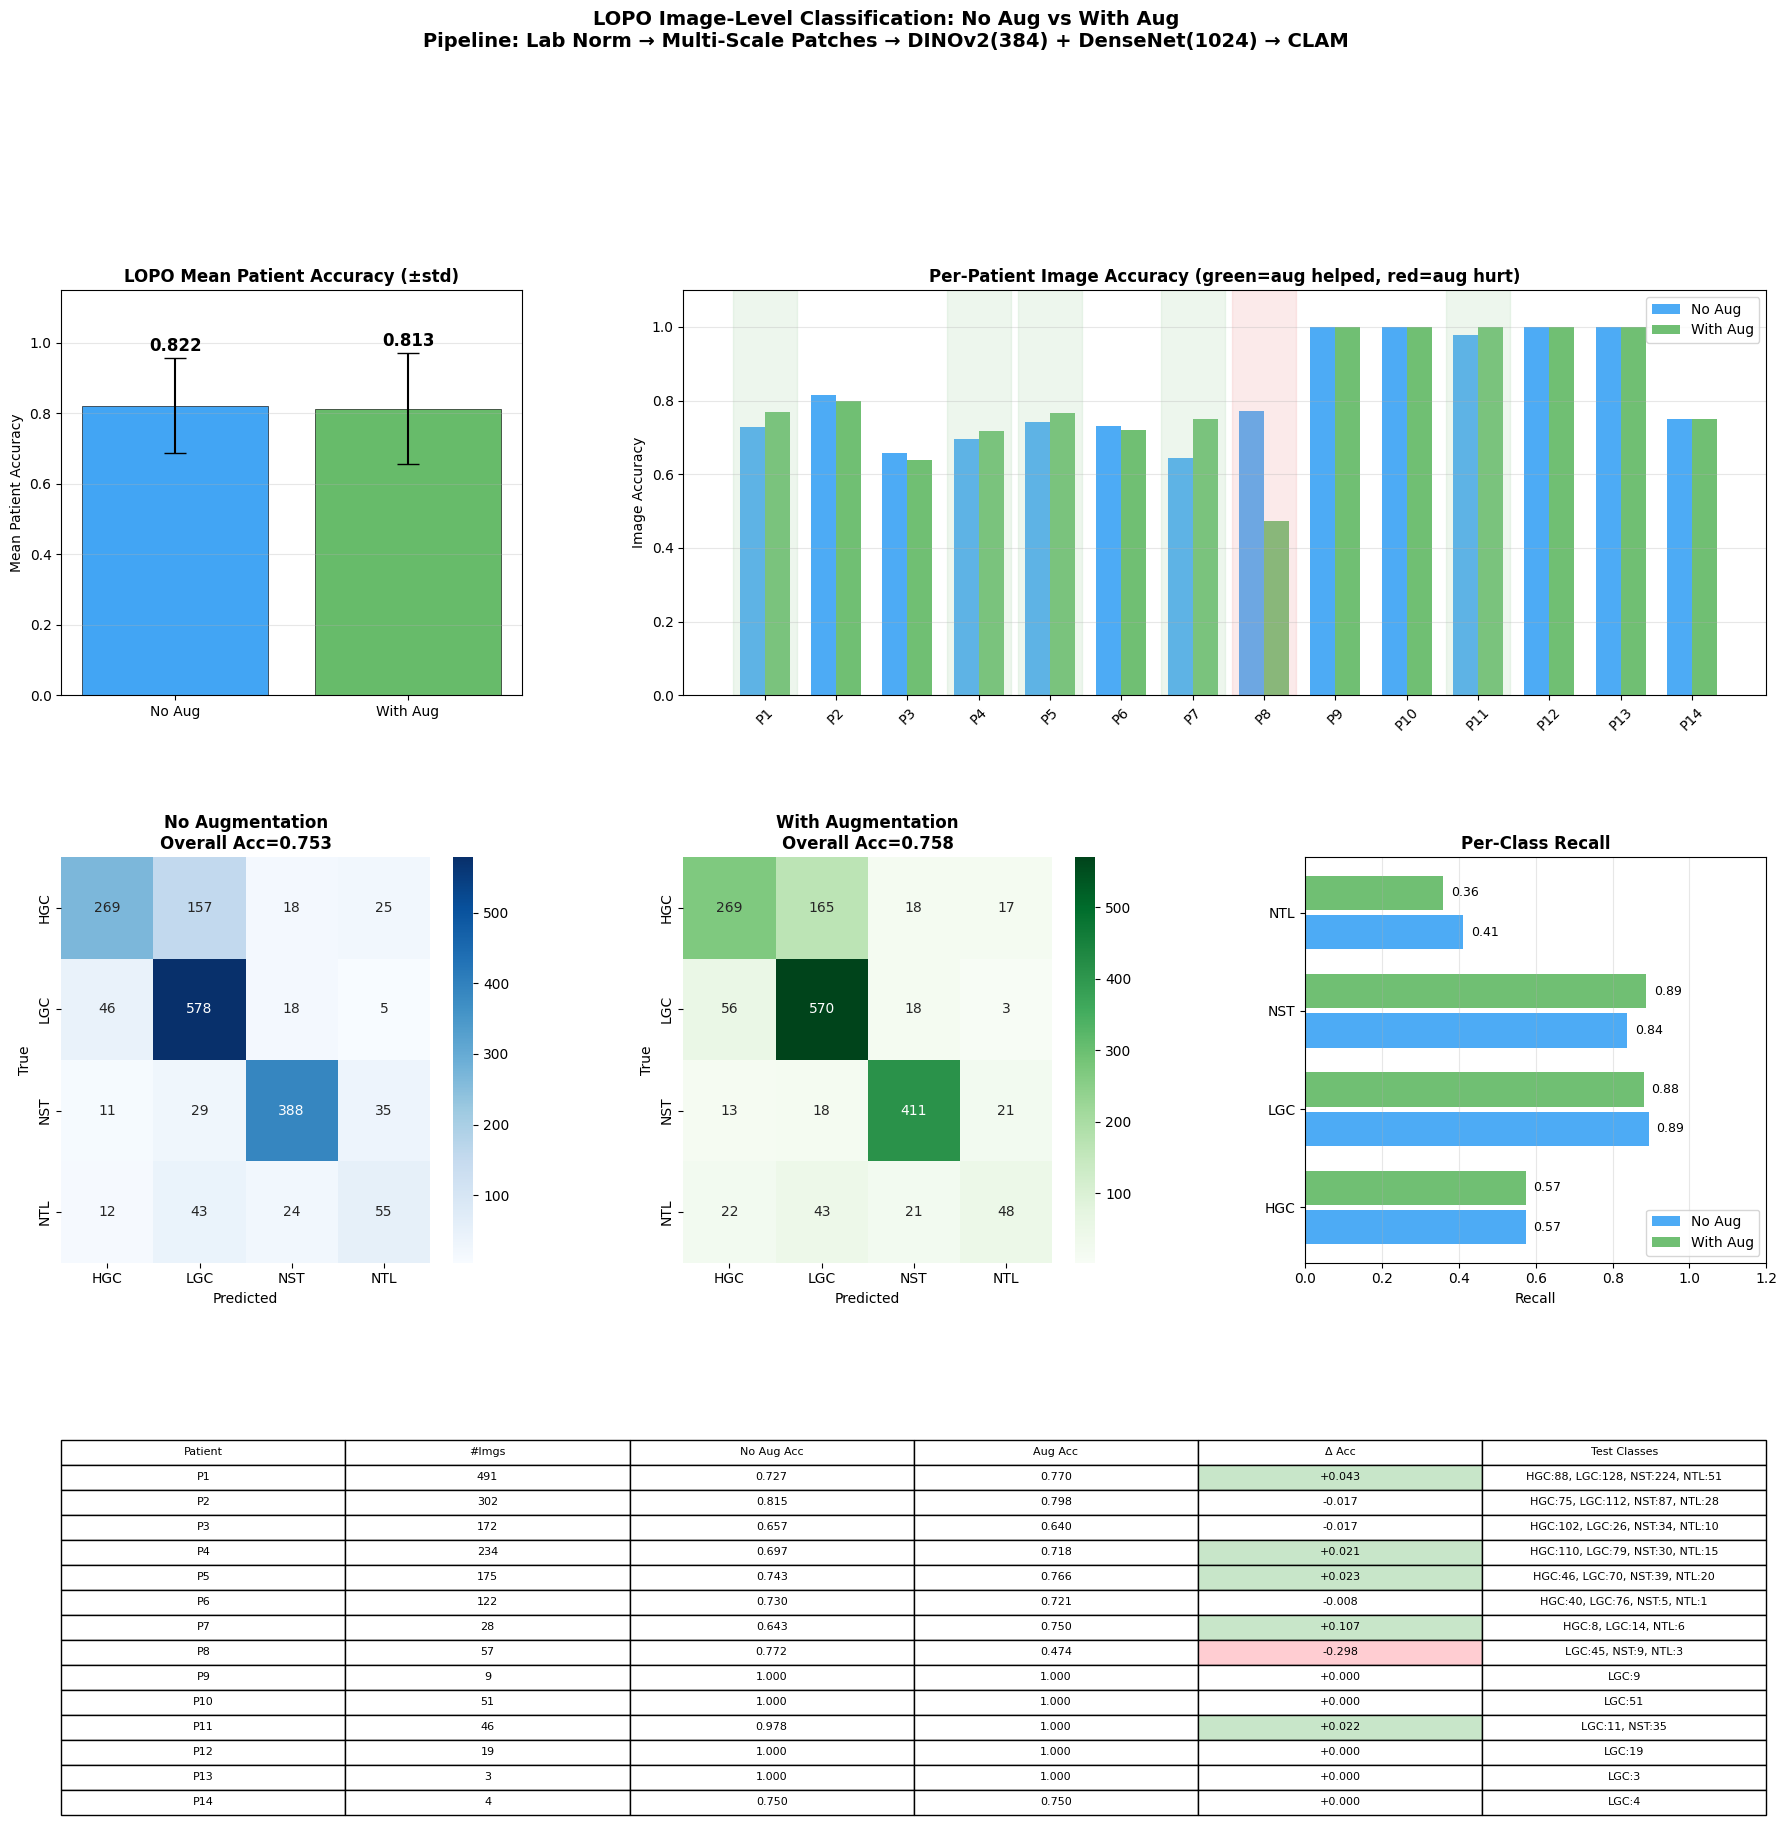

✓ Saved lopo_comparison.png


In [13]:
# ============================================================
# CELL 13: VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(22, 20))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# ---- 1. Overall accuracy bars ----
ax1 = fig.add_subplot(gs[0, 0])
methods = ['No Aug', 'With Aug']
mean_accs = [results_no_aug['mean_patient_accuracy'],
             results_with_aug['mean_patient_accuracy']]
std_accs = [results_no_aug['std_patient_accuracy'],
            results_with_aug['std_patient_accuracy']]
colors = ['#2196F3', '#4CAF50']

bars = ax1.bar(methods, mean_accs, yerr=std_accs, capsize=8,
               color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, acc, std in zip(bars, mean_accs, std_accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.02,
             f'{acc:.3f}', ha='center', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Patient Accuracy')
ax1.set_title('LOPO Mean Patient Accuracy (±std)', fontweight='bold')
ax1.set_ylim(0, 1.15)
ax1.grid(axis='y', alpha=0.3)

# ---- 2. Per-patient accuracy bars ----
ax2 = fig.add_subplot(gs[0, 1:])
pids = [f"P{f['patient']}" for f in results_no_aug['folds']]
na_accs = [f['image_accuracy'] for f in results_no_aug['folds']]
wa_accs = [f['image_accuracy'] for f in results_with_aug['folds']]

x = np.arange(len(pids))
w = 0.35
ax2.bar(x - w/2, na_accs, w, label='No Aug', color='#2196F3', alpha=0.8)
ax2.bar(x + w/2, wa_accs, w, label='With Aug', color='#4CAF50', alpha=0.8)

# Highlight where augmentation helped or hurt
for i in range(len(pids)):
    delta = wa_accs[i] - na_accs[i]
    if abs(delta) > 0.02:
        color = '#A5D6A7' if delta > 0 else '#EF9A9A'
        ax2.axvspan(i - 0.45, i + 0.45, alpha=0.2, color=color)

ax2.set_ylabel('Image Accuracy')
ax2.set_title('Per-Patient Image Accuracy (green=aug helped, red=aug hurt)',
              fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(pids, rotation=45)
ax2.legend()
ax2.set_ylim(0, 1.1)
ax2.grid(axis='y', alpha=0.3)

# ---- 3. Confusion — No aug ----
ax3 = fig.add_subplot(gs[1, 0])
cm1 = np.array(results_no_aug['overall_confusion'])
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=CFG.class_names, yticklabels=CFG.class_names, ax=ax3)
ax3.set_xlabel('Predicted'); ax3.set_ylabel('True')
na_overall = results_no_aug['overall_image_accuracy']
ax3.set_title(f'No Augmentation\nOverall Acc={na_overall:.3f}', fontweight='bold')

# ---- 4. Confusion — With aug ----
ax4 = fig.add_subplot(gs[1, 1])
cm2 = np.array(results_with_aug['overall_confusion'])
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=CFG.class_names, yticklabels=CFG.class_names, ax=ax4)
ax4.set_xlabel('Predicted'); ax4.set_ylabel('True')
wa_overall = results_with_aug['overall_image_accuracy']
ax4.set_title(f'With Augmentation\nOverall Acc={wa_overall:.3f}', fontweight='bold')

# ---- 5. Per-class recall comparison ----
ax5 = fig.add_subplot(gs[1, 2])
na_recall = []
wa_recall = []
for i in range(CFG.num_classes):
    na_total = cm1[i].sum()
    wa_total = cm2[i].sum()
    na_recall.append(cm1[i, i] / max(na_total, 1))
    wa_recall.append(cm2[i, i] / max(wa_total, 1))

y_pos = np.arange(CFG.num_classes)
ax5.barh(y_pos - 0.2, na_recall, 0.35, label='No Aug',
         color='#2196F3', alpha=0.8)
ax5.barh(y_pos + 0.2, wa_recall, 0.35, label='With Aug',
         color='#4CAF50', alpha=0.8)
for i in range(CFG.num_classes):
    ax5.text(na_recall[i] + 0.02, i - 0.2, f'{na_recall[i]:.2f}',
             va='center', fontsize=9)
    ax5.text(wa_recall[i] + 0.02, i + 0.2, f'{wa_recall[i]:.2f}',
             va='center', fontsize=9)
ax5.set_yticks(y_pos)
ax5.set_yticklabels(CFG.class_names)
ax5.set_xlabel('Recall')
ax5.set_title('Per-Class Recall', fontweight='bold')
ax5.legend(loc='lower right')
ax5.set_xlim(0, 1.2)
ax5.grid(axis='x', alpha=0.3)

# ---- 6. Summary table ----
ax6 = fig.add_subplot(gs[2, :])
ax6.axis('off')

headers = ['Patient', '#Imgs', 'No Aug Acc', 'Aug Acc', 'Δ Acc', 'Test Classes']
rows = []
for fna, fa in zip(results_no_aug['folds'], results_with_aug['folds']):
    delta = fa['image_accuracy'] - fna['image_accuracy']
    dist_str = ", ".join(f"{k}:{v}" for k, v in sorted(fna['distribution'].items()))
    rows.append([
        f"P{fna['patient']}",
        str(fna['n_test_images']),
        f"{fna['image_accuracy']:.3f}",
        f"{fa['image_accuracy']:.3f}",
        f"{delta:+.3f}",
        dist_str
    ])

table = ax6.table(cellText=rows, colLabels=headers, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

for i, row in enumerate(rows):
    delta_val = float(row[4])
    if delta_val > 0.02:
        table[i+1, 4].set_facecolor('#C8E6C9')
    elif delta_val < -0.02:
        table[i+1, 4].set_facecolor('#FFCDD2')

fig.suptitle(
    f'LOPO Image-Level Classification: No Aug vs With Aug\n'
    f'Pipeline: Lab Norm → Multi-Scale Patches → {backbone_desc} → CLAM',
    fontsize=14, fontweight='bold', y=1.02
)
plt.savefig('lopo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved lopo_comparison.png")

In [14]:
# ============================================================
# CELL 14: FINAL SUMMARY + EXPORT
# ============================================================

delta_mean = (results_with_aug['mean_patient_accuracy'] -
              results_no_aug['mean_patient_accuracy'])
delta_overall = (results_with_aug['overall_image_accuracy'] -
                 results_no_aug['overall_image_accuracy'])

improved = sum(1 for a, b in zip(results_no_aug['folds'], results_with_aug['folds'])
               if b['image_accuracy'] > a['image_accuracy'] + 0.01)
degraded = sum(1 for a, b in zip(results_no_aug['folds'], results_with_aug['folds'])
               if b['image_accuracy'] < a['image_accuracy'] - 0.01)
same = N_PATIENTS - improved - degraded

print(f"""
{'='*65}
  FINAL RESULTS
{'='*65}

  Pipeline: Lab Norm → Multi-Scale Patches → {backbone_desc} → CLAM
  Evaluation: LOPO ({N_PATIENTS} folds), {CFG.n_ensemble}-seed ensemble
  Early stopping: patience={CFG.patience}
  Class-weighted loss: Yes

  ┌────────────────────────┬──────────────────┬──────────────────┐
  │ Metric                 │ No Augmentation  │ With Augmentation│
  ├────────────────────────┼──────────────────┼──────────────────┤
  │ Mean Patient Acc       │ {results_no_aug['mean_patient_accuracy']:.4f} ± {results_no_aug['std_patient_accuracy']:.4f}  │ {results_with_aug['mean_patient_accuracy']:.4f} ± {results_with_aug['std_patient_accuracy']:.4f}  │
  │ Mean Patient Bal Acc   │ {results_no_aug['mean_patient_balanced']:.4f} ± {results_no_aug['std_patient_balanced']:.4f}  │ {results_with_aug['mean_patient_balanced']:.4f} ± {results_with_aug['std_patient_balanced']:.4f}  │
  │ Overall Image Acc      │ {results_no_aug['overall_image_accuracy']:.4f}           │ {results_with_aug['overall_image_accuracy']:.4f}           │
  │ Overall Balanced Acc   │ {results_no_aug['overall_balanced_accuracy']:.4f}           │ {results_with_aug['overall_balanced_accuracy']:.4f}           │
  │ Total Correct/Total    │ {results_no_aug['total_correct']}/{results_no_aug['total_images']}           │ {results_with_aug['total_correct']}/{results_with_aug['total_images']}           │
  ├────────────────────────┼──────────────────┴──────────────────┤
  │ Δ Mean Patient Acc     │ {delta_mean:+.4f}                            │
  │ Δ Overall Image Acc    │ {delta_overall:+.4f}                            │
  │ Patients improved      │ {improved}/{N_PATIENTS}                               │
  │ Patients degraded      │ {degraded}/{N_PATIENTS}                               │
  │ Patients similar       │ {same}/{N_PATIENTS}                               │
  └────────────────────────┴─────────────────────────────────────┘

  Total runtime: {total_time/60:.1f} minutes

{'='*65}
""")

# ---- Save JSON ----
summary = {
    'pipeline': f'Lab_Norm + MultiScale + {backbone_desc} + CLAM',
    'evaluation': 'LOPO',
    'classes': CFG.class_names,
    'n_patients': N_PATIENTS,
    'total_images': len(df),
    'no_augmentation': {
        'mean_patient_acc': results_no_aug['mean_patient_accuracy'],
        'std_patient_acc': results_no_aug['std_patient_accuracy'],
        'mean_patient_bal': results_no_aug['mean_patient_balanced'],
        'std_patient_bal': results_no_aug['std_patient_balanced'],
        'overall_image_acc': results_no_aug['overall_image_accuracy'],
        'overall_balanced_acc': results_no_aug['overall_balanced_accuracy'],
        'total_correct': results_no_aug['total_correct'],
        'total_images': results_no_aug['total_images'],
        'confusion_matrix': results_no_aug['overall_confusion'],
        'folds': results_no_aug['folds']
    },
    'with_augmentation': {
        'mean_patient_acc': results_with_aug['mean_patient_accuracy'],
        'std_patient_acc': results_with_aug['std_patient_accuracy'],
        'mean_patient_bal': results_with_aug['mean_patient_balanced'],
        'std_patient_bal': results_with_aug['std_patient_balanced'],
        'overall_image_acc': results_with_aug['overall_image_accuracy'],
        'overall_balanced_acc': results_with_aug['overall_balanced_accuracy'],
        'total_correct': results_with_aug['total_correct'],
        'total_images': results_with_aug['total_images'],
        'confusion_matrix': results_with_aug['overall_confusion'],
        'folds': results_with_aug['folds']
    },
    'comparison': {
        'delta_mean_patient_acc': delta_mean,
        'delta_overall_image_acc': delta_overall,
        'patients_improved': improved,
        'patients_degraded': degraded,
        'patients_similar': same
    },
    'config': {
        'patch_scales': CFG.patch_scales,
        'max_patches_per_image': CFG.max_patches_per_image,
        'feature_dim': CFG.feat_dim,
        'backbone': backbone_desc,
        'mil_model': 'CLAM',
        'clam_k_sample': CFG.clam_k_sample,
        'epochs': CFG.epochs,
        'early_stopping_patience': CFG.patience,
        'lr': CFG.lr,
        'n_ensemble': CFG.n_ensemble,
        'n_augments': CFG.n_augments,
        'class_weighted_loss': True,
        'augmentations': [
            'rotation_360', 'hflip', 'vflip',
            'color_jitter(b=0.2,c=0.2,s=0.15,h=0.01)',
            'gaussian_blur(p=0.2)',
            'gaussian_noise(p=0.15)',
            'affine(t=0.05,s=0.95-1.05)'
        ],
        'total_runtime_minutes': total_time / 60
    }
}

with open('lopo_results.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print("✓ Saved lopo_results.json")

# ---- Save per-patient CSV ----
rows = []
for fna, fa in zip(results_no_aug['folds'], results_with_aug['folds']):
    rows.append({
        'patient': fna['patient'],
        'n_test_images': fna['n_test_images'],
        'no_aug_acc': round(fna['image_accuracy'], 4),
        'no_aug_bal': round(fna['balanced_accuracy'], 4),
        'no_aug_conf': round(fna['mean_confidence'], 4),
        'aug_acc': round(fa['image_accuracy'], 4),
        'aug_bal': round(fa['balanced_accuracy'], 4),
        'aug_conf': round(fa['mean_confidence'], 4),
        'delta_acc': round(fa['image_accuracy'] - fna['image_accuracy'], 4)
    })
pd.DataFrame(rows).to_csv('lopo_per_patient.csv', index=False)
print("✓ Saved lopo_per_patient.csv")

# ---- Save overall classification reports ----
with open('classification_report_no_aug.txt', 'w') as f:
    f.write(f"WITHOUT AUGMENTATION\n{'='*50}\n\n")
    f.write(classification_report(
        results_no_aug['all_y_true'], results_no_aug['all_y_pred'],
        target_names=CFG.class_names, zero_division=0
    ))

with open('classification_report_with_aug.txt', 'w') as f:
    f.write(f"WITH AUGMENTATION\n{'='*50}\n\n")
    f.write(classification_report(
        results_with_aug['all_y_true'], results_with_aug['all_y_pred'],
        target_names=CFG.class_names, zero_division=0
    ))

print("✓ Saved classification reports")
print(f"\n{'='*65}")
print("  ALL DONE")
print(f"{'='*65}")


  FINAL RESULTS

  Pipeline: Lab Norm → Multi-Scale Patches → DINOv2(384) + DenseNet(1024) → CLAM
  Evaluation: LOPO (14 folds), 3-seed ensemble
  Early stopping: patience=15
  Class-weighted loss: Yes

  ┌────────────────────────┬──────────────────┬──────────────────┐
  │ Metric                 │ No Augmentation  │ With Augmentation│
  ├────────────────────────┼──────────────────┼──────────────────┤
  │ Mean Patient Acc       │ 0.8222 ± 0.1357  │ 0.8133 ± 0.1581  │
  │ Mean Patient Bal Acc   │ 0.7873 ± 0.1828  │ 0.7807 ± 0.1864  │
  │ Overall Image Acc      │ 0.7531           │ 0.7577           │
  │ Overall Balanced Acc   │ 0.6788           │ 0.6751           │
  │ Total Correct/Total    │ 1290/1713           │ 1298/1713           │
  ├────────────────────────┼──────────────────┴──────────────────┤
  │ Δ Mean Patient Acc     │ -0.0089                            │
  │ Δ Overall Image Acc    │ +0.0047                            │
  │ Patients improved      │ 5/14                      